## Chapter 9: Unsupervised Learning
When we only have input data X, but labels y are not available.

## K Means Clustering:
Before training the model, standard scale X such that all attributes have the same variance.

Randomly pick k points as centroids, then assign each instance to its closest centroid based on squared euclidean distance.
Update centroids by taking the mean of all instances in each cluster. Then repeat the steps until new centroids = old centroids. 

K Means is guaranteed to converge, and it is a fast algorithm. 

However, each run may result in different clusterings. The result depends on the centroid initialization step. There are also some ideal conditions to be met in order for K Means to produce the most useful results, such as the clusters should be in similar sizes, sparsity; the clusters should be spherical; the data should not have outliers.

In [ ]:
# suppose df is already imported, and X = df.copy()
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, n_init='auto', random_state=0)             # specify the number of clusters you want. random_state can fix centroid initialization step. n_init is the number of iterations you want
kmeans.fit(X)

kmeans.labels_                                                  # 输出每个instance的分类结果
df['predicted_cluster'] = kmeans.labels_                        # 把每一个instance的分类结果作为新的一列添加到df中

kmeans.cluster_centers_                                         # 输出最终找到的centroid的坐标

kmeans.predict(X_new)                                           # 用训练结果，对新的instance进行cluster的预测
kmeans.transform(X_new)                                         # 输出new instance到每一个centroid的距离。每行代表一个new instance，每列代表到centroid 0 ... k的距离。如果X_new有m instances, then this code will output a m*k matrix。

kmeans.inertia_                                                 # 输出这个clustering result的inertia, which is the sum of each instance's sqrd euclidean distance to the centroid it is assigned to. Smaller inertia generally means better clustering result.

## Mini-Batch K-Means:
Mini-Batch K Means is much faster than K Means when the number of centroids is large, but it will result in higher inertia than K Means. So there is a trade-off between run time and clustering result quality.

In [ ]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5)
minibatch_kmeans.fit(X)

## How to decide the optimal number of centroids?
By displaying K Means elbow plot (k value vs clustering inertia value), K Means average silhouette score plot (k value vs clustering avg sil score), and silhouette diagrams for each k (plot each instance's silhouette score on a histogram).

We want to pick a k value that is close to the elbow in the elbow plot, yields a relatively high average silhouette score, and produces clusters of similar sizes.

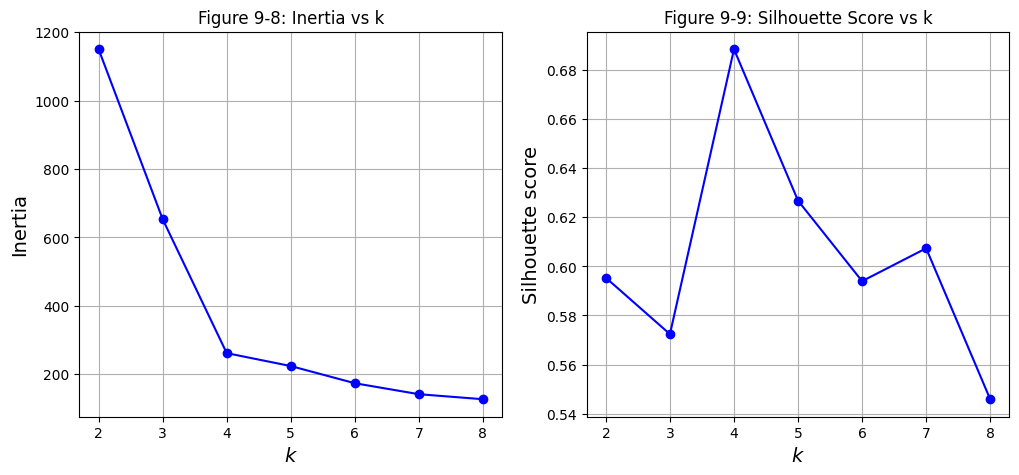

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. 创建虚拟数据
blob_centers = np.array([
    [0.2, 2.3], 
    [-1.5, 2.3], 
    [-2.8, 1.8], 
    [-2.8, 2.8], 
    [-2.8, 1.3]
])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=7)

# 2. 循环训练多个 K 值，收集 Inertia 和 轮廓系数
k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# 3. 绘制 Figure 9-8: 手肘法
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.title("Figure 9-8: Inertia vs k")
plt.grid(True)

# 4. 绘制 Figure 9-9: 轮廓系数
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Figure 9-9: Silhouette Score vs k")
plt.grid(True)

plt.show()

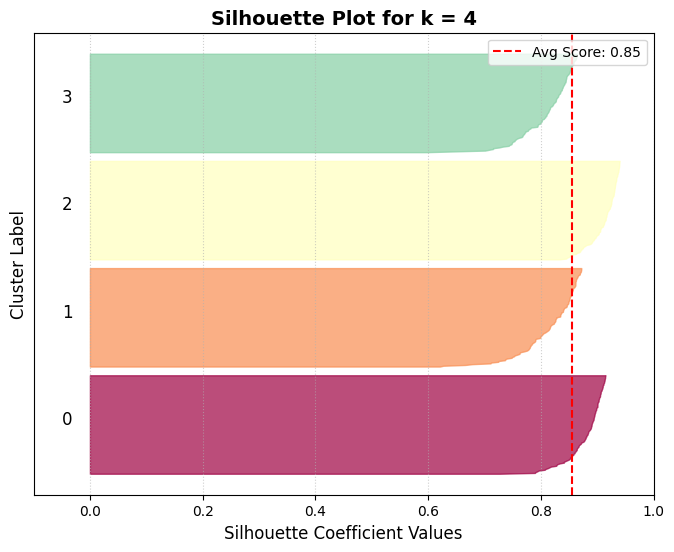

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
import matplotlib

# 忽略所有警告（包括弃用警告和字体警告）
warnings.filterwarnings("ignore")
matplotlib.rcParams['axes.unicode_minus'] = False  # 顺便修复负号显示问题

# 1. 创建虚拟数据（以便直接运行演示）
X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=0.7, random_state=42)

# 2. 定义你想查看的聚类数量 K
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X)

# 3. 计算核心指标
# silhouette_avg: 所有点的平均轮廓系数（对应图中的红虚线）
silhouette_avg = silhouette_score(X, cluster_labels)
# sample_silhouette_values: 每一个点的具体轮廓系数（对应直方图的条形长度）
sample_silhouette_values = silhouette_samples(X, cluster_labels)

# 4. 开始画图
plt.figure(figsize=(8, 6))

y_lower = 10 # 起始的 y 轴高度
for i in range(k):
    # 提取第 i 个聚类中所有样本点的轮廓系数，并进行排序
    ith_cluster_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_values.sort() # 从小到大排序，从而形成平滑的直方“山峰”
    
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    # 为不同的簇选择不同的颜色
    color = cm.get_cmap("Spectral")(float(i) / k)
    
    # fill_betweenx 用于绘制水平的直方条形图
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    # 在 y 轴正中标签注明当前是第几个 Cluster
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=12)
    
    # 计算下一个 Cluster 的起始 y 轴高度（留出 10 个单位的间隙）
    y_lower = y_upper + 10  

# 5. 美化图表
plt.title(f"Silhouette Plot for k = {k}", fontsize=14, fontweight='bold')
plt.xlabel("Silhouette Coefficient Values", fontsize=12)
plt.ylabel("Cluster Label", fontsize=12)

# 绘制红色垂直虚线，代表整体的平均轮廓得分
plt.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Avg Score: {silhouette_avg:.2f}")

plt.xlim([-0.1, 1.0]) # 轮廓系数的范围在 [-1, 1] 之间，通常主要看 0 以上的部分
plt.yticks([])        # 隐藏原本无意义的 y 轴刻度数字
plt.legend(loc="upper right")
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

## K Means Application 1: Color segmentation
我们需要用的是png图片。为了获得png格式，用预览打开一个图片，然后在“导出”中选择导出格式为png格式。

下一步是在python中导入png格式图片。把图片拖入terminal获得图片路径，然后在image_path = os.path.join()中输入图片路径，然后image = imread(image_path)导入。

png图片的shape是(height, width, 3). 索引一个pixel的方法是：image[x, y]，然后得到这个pixel的RGB对应数值。
一个更常用的方法是把图片用reshape(-1, 3)函数 (即固定死reshape之后的列数是3，让python自己计算行数)去reshape成一个m*3的矩阵。

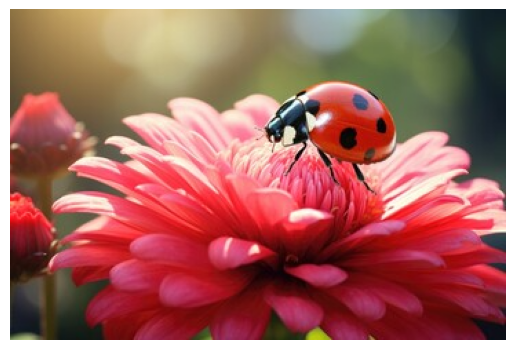

In [1]:
import os
from matplotlib.image import imread
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

image_path = os.path.join("/", "Users", "yangmolin", "Desktop", "2026 summer learning", "Hands on ML notes", "ladybug.png")     # 导入本地图片的方法，找到图片路径的方法是把图片拖入终端，然后把路径复制过来即可
image = imread(image_path)
plt.imshow(image)
plt.axis("off")
plt.show()

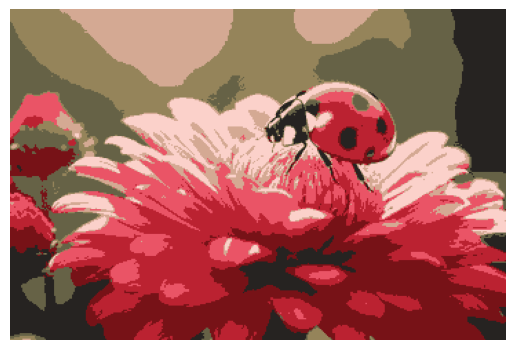

In [2]:
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters=8).fit(X)                        # 用K Means在RGB三位颜色空间中寻找8个代表性中心色
segmented_img = kmeans.cluster_centers_[kmeans.labels_]     # 颜色替换：用聚类的中心色（8种颜色）替换原图中几万种像素点的颜色
segmented_img = segmented_img.reshape(image.shape)          # 恢复形状：把 2D 矩阵重新恢复成 3D 图片的宽高结构
plt.imshow(segmented_img)
plt.axis("off")
plt.show()

## K Means Application 2: Data Preprocessing
用k means找出centroid，对于每一个instance，计算它到每个centroid的距离: [d1, d2, ... dk]。然后用这个新的m*k dimensional dataset训练logistic classifier。classifier的accuracy往往会比不用k means训练更高。

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

X_digits, y_digits = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits)

pipeline = Pipeline([
 ("kmeans", KMeans(n_clusters=50)),
 ("log_reg", LogisticRegression()),
])

param_grid = dict(kmeans__n_clusters=range(2, 100))

grid_clf = GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(X_train, y_train)
grid_clf.score(X_test, y_test)